Loading the unhealthy dataset

In [1]:

# Import necessary libraries
import cv2
import os
from PIL import Image
import time
import matplotlib.pyplot as plt
import numpy as np



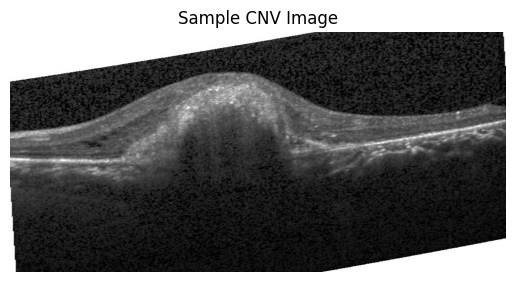

In [2]:

import cv2, os
from pathlib import Path

folder_path = Path("Data/CellData/OCT/test/CNV")
images_unhealthy = []

for file in folder_path.iterdir():
    if file.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)  # returns a NumPy array
        if img is not None:
            images_unhealthy.append(img)

plt.imshow(images_unhealthy[3], cmap='gray')
plt.axis('off')
plt.title('Sample CNV Image')
plt.show()

Loading the healthy dataset

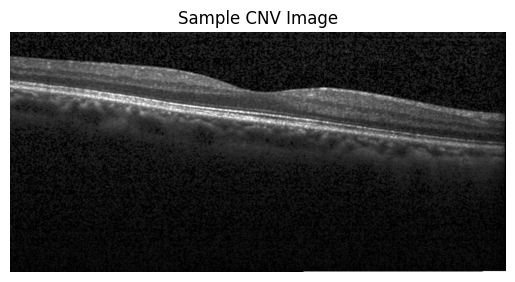

In [3]:

import cv2, os
from pathlib import Path

folder_path = Path("Data/CellData/OCT/test/Normal")
images_healthy = []

for file in folder_path.iterdir():
    if file.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)  # returns a NumPy array
        if img is not None:
            images_healthy.append(img)

plt.imshow(images_healthy[3], cmap='gray')
plt.axis('off')
plt.title('Sample CNV Image')
plt.show()



Loading train Healthy

In [ ]:
import cv2, os
from pathlib import Path

folder_path = Path("Data/CellData/OCT/train/Normal")
images_healthy_train = []

for file in folder_path.iterdir():
    if file.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)  # returns a NumPy array
        if img is not None:
            images_healthy_train.append(img)


train unhealthy

In [ ]:
import cv2, os
from pathlib import Path

folder_path = Path("Data/CellData/OCT/train/CNV")
images_unhealthy_train = []

for file in folder_path.iterdir():
    if file.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)  # returns a NumPy array
        if img is not None:
            images_unhealthy_train.append(img)


Remove borders

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Function to replace white border pixels with black
def remove_white_borders(arr, threshold=250):
    """
    Replace white pixels (>= threshold) with black (0).
    Works for 2D grayscale images.
    """
    arr = arr.copy()
    mask = arr >= threshold
    arr[mask] = 0
    return arr

# 🔄 Modify the existing arrays directly
for i in range(len(images_unhealthy)):
    images_unhealthy[i] = remove_white_borders(images_unhealthy[i])

for i in range(len(images_healthy)):
    images_healthy[i] = remove_white_borders(images_healthy[i])

for i in range(len(images_unhealthy_train)):
    images_unhealthy_train[i] = remove_white_borders(images_unhealthy_train[i])

for i in range(len(images_healthy_train)):
    images_healthy_train[i] = remove_white_borders(images_healthy_train[i])

print(f"Updated {len(images_unhealthy)} unhealthy and {len(images_healthy)} healthy images (white borders set to black).")

# Show before and after for one example
idx = 4
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(images_unhealthy_train[idx], cmap='gray')
plt.axis('off')
plt.title('Unhealthy (Borders → Black)')

plt.subplot(1, 2, 2)
plt.imshow(images_healthy_train[idx], cmap='gray')
plt.axis('off')
plt.title('Healthy (Borders → Black)')

plt.show()



In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def _ensure_odd_kernel(k):
    # Make sure Gaussian kernel size is valid (odd, >=1)
    if isinstance(k, int):
        return (k if k % 2 == 1 else k + 1)
    kh = k[0] if isinstance(k, tuple) else k
    kw = k[1] if isinstance(k, tuple) else k
    kh = kh if kh % 2 == 1 else kh + 1
    kw = kw if kw % 2 == 1 else kw + 1
    return (max(1, kh), max(1, kw))

def _to_gray_array(img):
    """Accepts np.ndarray (gray or RGB/BGR) or PIL.Image; returns 2D uint8 array."""
    if isinstance(img, np.ndarray):
        if img.ndim == 2:
            return img.astype(np.uint8, copy=False)
        elif img.ndim == 3:
            # Assume BGR (cv2) or RGB; if unsure, convert by averaging channels
            # Safer universal path: convert to gray with cv2 (assumes BGR)
            try:
                return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            except cv2.error:
                # Fallback: average channels
                return np.clip(img.mean(axis=2), 0, 255).astype(np.uint8)
    else:
        # PIL.Image
        return np.array(img.convert("L"), dtype=np.uint8)

def enhance_low_high_np(img, blur_kernel=(27, 27), highpass_weight=1.0, keep_type='ndarray'):
    """
    Apply Gaussian low-pass + high-pass enhancement.
    Accepts: np.ndarray or PIL.Image
    Returns: np.ndarray (grayscale) by default; set keep_type='pil' to get PIL.Image
    """
    k = _ensure_odd_kernel(blur_kernel)
    arr = _to_gray_array(img).astype(np.float32)

    # Low-pass (Gaussian blur)
    blurred = cv2.GaussianBlur(arr, k, 0)

    # High-pass
    highpass = arr - blurred

    # Combine
    sharpened = cv2.addWeighted(arr, 1.0, highpass, float(highpass_weight), 0)

    # Clip back to valid range
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    if keep_type == 'pil':
        return Image.fromarray(sharpened)
    return sharpened

# 🧠 Apply to all images (lists may contain NumPy arrays now)
images_unhealthy_enhanced       = [enhance_low_high_np(img) for img in images_unhealthy]
images_healthy_enhanced         = [enhance_low_high_np(img) for img in images_healthy]
images_unhealthy_train_enhanced = [enhance_low_high_np(img) for img in images_unhealthy_train]
images_healthy_train_enhanced   = [enhance_low_high_np(img) for img in images_healthy_train]

print(f"Enhanced {len(images_unhealthy_enhanced)} unhealthy images and {len(images_healthy_enhanced)} healthy images.")

# 🔍 Show one example from each
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(images_unhealthy_train_enhanced[5], cmap='gray')
plt.axis('off')
plt.title('Unhealthy Enhanced')

plt.subplot(1, 2, 2)
plt.imshow(images_healthy_train_enhanced[5], cmap='gray')
plt.axis('off')
plt.title('Healthy Enhanced')

plt.show()

del images_unhealthy_train
del images_healthy_train
del images_unhealthy
del images_healthy


Filter

Only keep bright pixels

Line detection

Reverse colors to deteckt black pockets -> add them to the detect lines thingy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image

def keep_inverted_top_band(pil_list, delta=20):
    """
    For each PIL 'L' image:
      - convert to grayscale ndarray
      - invert: new_pixel = 255 - old_pixel
      - find max intensity in inverted image
      - threshold at max - delta
      - keep original inverted values where >= threshold, else 0 (black)
    Returns list of uint8 numpy arrays.
    """
    out = []
    for im in pil_list:
        # ensure grayscale ndarray
        if isinstance(im, PIL.Image.Image):
            g = np.array(im.convert("L"), dtype=np.uint8)
        else:
            g = np.array(im, dtype=np.uint8)
        
        # invert the grayscale image
        inv = 255 - g
        
        # compute threshold
        maxv = int(inv.max())
        thr = max(0, maxv - int(delta))
        
        # keep only bright (white) pixels in inverted image
        keep = (inv >= thr)
        result = np.where(keep, inv, 0).astype(np.uint8)
        out.append(result)
    return out

# Apply to your variables
unhealthy_inv_top = keep_inverted_top_band(images_unhealthy_enhanced, delta=70)
healthy_inv_top   = keep_inverted_top_band(images_healthy_enhanced,   delta=70)
unhealthy_inv_top_train = keep_inverted_top_band(images_unhealthy_train_enhanced, delta=70)
healthy_inv_top_train   = keep_inverted_top_band(images_healthy_train_enhanced,   delta=70)

# Quick visual check
idx = 6
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(unhealthy_inv_top[idx], cmap='gray'); plt.axis('off'); plt.title('Unhealthy (inverted) ≥ (max-70)')
plt.subplot(1,2,2); plt.imshow(healthy_inv_top[idx],   cmap='gray'); plt.axis('off');  plt.title('Healthy (inverted) ≥ (max-70)')
plt.show()

del images_unhealthy_train_enhanced
del images_healthy_train_enhanced
del images_unhealthy_enhanced
del images_healthy_enhanced



noise removal

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def keep_main_object_preserve_intensity_batch(pil_list, thresh_val=110, morph_kernel=5, return_array=True):
    """
    Apply 'keep_main_object_preserve_intensity' to every image in pil_list.
    Accepts list/array of images (NumPy or PIL), returns list or stacked array.
    """
    out = []

    # structuring element once
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel, morph_kernel))

    for im in pil_list:
        # --- normalize input to grayscale uint8 NumPy array ---
        if isinstance(im, Image.Image):        # PIL
            if im.mode != "L":
                im = im.convert("L")
            img = np.array(im)
        else:
            img = np.asarray(im)
            if img.ndim == 3:                  # RGB/BGR -> gray
                # assume RGB ordering; if your data is BGR, swap code to COLOR_BGR2GRAY
                img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        img = img.astype(np.uint8)

        # --- threshold dark regions ---
        _, mask = cv2.threshold(img, thresh_val, 255, cv2.THRESH_BINARY_INV)

        # --- morphological cleanup ---
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)

        # --- keep largest component only ---
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        if num_labels > 1:
            largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            mask = np.where(labels == largest_label, 255, 0).astype(np.uint8)
        else:
            # only background or one component; ensure mask is binary {0,255}
            mask = (labels == 1).astype(np.uint8) * 255 if num_labels == 2 else mask

        # --- preserve interior, set outside to 255 ---
        result = np.where(mask == 255, img, 255).astype(np.uint8)
        out.append(result)

    if return_array and isinstance(pil_list, np.ndarray):
        return np.stack(out)
    return out

# Process all splits
unhealthy_processed_all       = keep_main_object_preserve_intensity_batch(unhealthy_inv_top)
healthy_processed_all         = keep_main_object_preserve_intensity_batch(healthy_inv_top)
unhealthy_train_processed_all = keep_main_object_preserve_intensity_batch(unhealthy_inv_top_train)
healthy_train_processed_all   = keep_main_object_preserve_intensity_batch(healthy_inv_top_train)

# Plot a single index for before/after
idx = 11
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes[0,0].imshow(unhealthy_inv_top[idx], cmap='gray');          axes[0,0].set_title("Unhealthy Original"); axes[0,0].axis('off')
axes[0,1].imshow(healthy_inv_top[idx], cmap='gray');            axes[0,1].set_title("Healthy Original");   axes[0,1].axis('off')
axes[1,0].imshow(unhealthy_processed_all[idx], cmap='gray');    axes[1,0].set_title("Unhealthy Cleaned");  axes[1,0].axis('off')
axes[1,1].imshow(healthy_processed_all[idx], cmap='gray');      axes[1,1].set_title("Healthy Cleaned");    axes[1,1].axis('off')
plt.tight_layout()
plt.show()

del unhealthy_inv_top
del healthy_inv_top
del unhealthy_inv_top_train
del healthy_inv_top_train

Bubble detection

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPClassifier

import cv2
import numpy as np
from collections import Counter

def most_common_hw(imgs):
    """Find the most common (H,W) among a list/array of images."""
    sizes = [np.asarray(im).shape[:2] for im in imgs]
    (H,W), _ = Counter(sizes).most_common(1)[0]
    return int(H), int(W)

def to_array_uniform(imgs, mode="resize", target_size=None, pad_value=255):
    """
    Convert a list/array of images to a stacked NumPy array with uniform shape.
    mode: "resize" (warp to target_size) or "pad" (pad to max or target_size).
    target_size: (H, W). If None, uses most common size for "resize",
                 or the max(H), max(W) seen for "pad".
    pad_value: value used for padding background (e.g., 255 for white).
    """
    # Normalize input to list
    if isinstance(imgs, np.ndarray) and imgs.ndim >= 3:
        seq = [imgs[i] for i in range(len(imgs))]
    else:
        seq = list(imgs)

    # Determine target size
    if target_size is None:
        if mode == "resize":
            target_size = most_common_hw(seq)
        elif mode == "pad":
            Hs, Ws = zip(*[np.asarray(im).shape[:2] for im in seq])
            target_size = (max(Hs), max(Ws))
    Ht, Wt = target_size

    out = []
    for im in seq:
        im = np.asarray(im)
        # ensure grayscale (H,W)
        if im.ndim == 3:
            # assume grayscale-like content; convert if needed
            if im.shape[2] == 3:
                im = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
            elif im.shape[2] == 4:
                im = cv2.cvtColor(im, cv2.COLOR_RGBA2GRAY)
            else:
                # keep channels if exotic; you'll then get (H,W,C)
                pass

        if mode == "resize":
            if im.ndim == 2:
                im_u = cv2.resize(im, (Wt, Ht), interpolation=cv2.INTER_NEAREST)
            else:
                # per-channel resize
                chans = [cv2.resize(im[...,c], (Wt, Ht), interpolation=cv2.INTER_NEAREST)
                         for c in range(im.shape[2])]
                im_u = np.stack(chans, axis=-1)
        elif mode == "pad":
            # place image at top-left; change here if you prefer centered padding
            if im.ndim == 2:
                im_u = np.full((Ht, Wt), pad_value, dtype=im.dtype)
                h, w = im.shape[:2]
                im_u[:h, :w] = im
            else:
                C = im.shape[2]
                im_u = np.full((Ht, Wt, C), pad_value, dtype=im.dtype)
                h, w = im.shape[:2]
                im_u[:h, :w, :] = im
        else:
            raise ValueError("mode must be 'resize' or 'pad'")
        out.append(im_u)

    return np.stack(out)

# ── Use it on your four splits ────────────────────────────────────────────────
# Pick one policy. Resizing is simplest for MLP input.
unhealthy_train_arr = to_array_uniform(unhealthy_train_processed_all, mode="resize")
healthy_train_arr   = to_array_uniform(healthy_train_processed_all,   mode="resize")
unhealthy_test_arr  = to_array_uniform(unhealthy_processed_all,       mode="resize")
healthy_test_arr    = to_array_uniform(healthy_processed_all,         mode="resize")

# If you prefer padding instead:
# unhealthy_train_arr = to_array_uniform(unhealthy_train_processed_all, mode="pad", pad_value=255)
# ...

# Now continue with your code (minor rename from uh_train/h_train/etc.)
uh_train = unhealthy_train_arr
h_train  = healthy_train_arr
uh_test  = unhealthy_test_arr
h_test   = healthy_test_arr


# Basic sanity checks
assert uh_train.ndim in (3,4) and h_train.ndim in (3,4), "Train arrays must be (N,H,W) or (N,H,W,C)"
assert uh_test.ndim in (3,4) and h_test.ndim in (3,4),  "Test arrays must be (N,H,W) or (N,H,W,C)"
assert uh_train.shape[1:-1] == h_train.shape[1:-1] if uh_train.ndim==4 and h_train.ndim==4 else uh_train.shape[1:3] == h_train.shape[1:3], "Train image sizes must match"
assert uh_test.shape[1:-1]  == h_test.shape[1:-1]  if uh_test.ndim==4 and h_test.ndim==4  else uh_test.shape[1:3]  == h_test.shape[1:3],  "Test image sizes must match"

# Figure out height/width/channels from training set
if uh_train.ndim == 4:  # (N,H,W,C)
    H, W, C = uh_train.shape[1:]
else:                   # (N,H,W)
    H, W = uh_train.shape[1:]
    C = 1

# ── 2) Build X/y (train and test) ─────────────────────────────────────────────
X_train_img = np.concatenate([h_train, uh_train], axis=0)
y_train = np.concatenate([
    np.zeros(len(h_train), dtype=np.int64),      # healthy = 0
    np.ones(len(uh_train), dtype=np.int64)       # unhealthy = 1
], axis=0)

X_test_img = np.concatenate([h_test, uh_test], axis=0)
y_test = np.concatenate([
    np.zeros(len(h_test), dtype=np.int64),
    np.ones(len(uh_test), dtype=np.int64)
], axis=0)

# ── 3) Flatten + normalize ────────────────────────────────────────────────────
def flatten_and_normalize(x):
    # If channels exist, leave them in the feature vector; MLP can handle it.
    x = x.astype(np.float32)
    # Auto-scale: if max > 1, assume 0–255 and scale to 0–1, else leave as is.
    x_max = np.max(x)
    if x_max > 1.0:
        x = x / 255.0
    return x.reshape(len(x), -1)

X_train = flatten_and_normalize(X_train_img)
X_test  = flatten_and_normalize(X_test_img)

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape,  "y_test  shape:", y_test.shape)

# ── 4) Define and train the MLP ───────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(40,),
    max_iter=8,
    alpha=1e-4,
    solver="sgd",
    verbose=10,
    random_state=1,
    learning_rate_init=0.2,
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")
    mlp.fit(X_train, y_train)



# ── 5) Inspect learned weight/bias shapes ─────────────────────────────────────
print("mlp.coefs_[0] shape (input→hidden):", mlp.coefs_[0].shape)   # (D, 40)
print("mlp.coefs_[1] shape (hidden→output):", mlp.coefs_[1].shape)  # (40, 2)
print("mlp.intercepts_[0] shape (hidden biases):", mlp.intercepts_[0].shape)  # (40,)
print("mlp.intercepts_[1] shape (output biases):", mlp.intercepts_[1].shape)  # (2,)
# Sanity: input dimension must match flattened image size
assert mlp.coefs_[0].shape[0] == X_train.shape[1], "Input size mismatch!"

# ── 6) Visualize first-layer weights as "filters" ─────────────────────────────
# For RGB/multi-channel, we average over channels for display.
def coef_to_image(coef_vector, H, W, C):
    if C == 1:
        return coef_vector.reshape(H, W)
    else:
        img = coef_vector.reshape(H, W, C)
        return img.mean(axis=2)  # average channels

num_neurons = mlp.coefs_[0].shape[1]
rows, cols = 5, min(8, num_neurons)  # 5×8 grid like before (adjust cols if fewer neurons)
fig, axes = plt.subplots(rows, cols, figsize=(10, 6))
axes = np.atleast_1d(axes).ravel()

vmin, vmax = mlp.coefs_[0].min(), mlp.coefs_[0].max()

for i, (coef, ax) in enumerate(zip(mlp.coefs_[0].T, axes)):
    img = coef_to_image(coef, H, W, C)
    ax.matshow(img, cmap=plt.cm.gray, vmin=0.5 * vmin, vmax=0.5 * vmax)
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(f"Neuron {i}", fontsize=8)

plt.tight_layout()
plt.show()
